# Caminos Más Cortos

En este caso, queremos representar las intersecciones de los caminos de una ciudad mediante vértices de un multi-grafo dirigido ponderado. La ponderación o peso de la arista corresponde al largo del segmento, por lo tanto podemos utilizar el algoritmo Dijsktra para calcular el costo de un camino entre dos puntos.

In [ ]:
%pip install haversine
%pip install osmnx

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Figure size 1500x400 with 0 Axes>

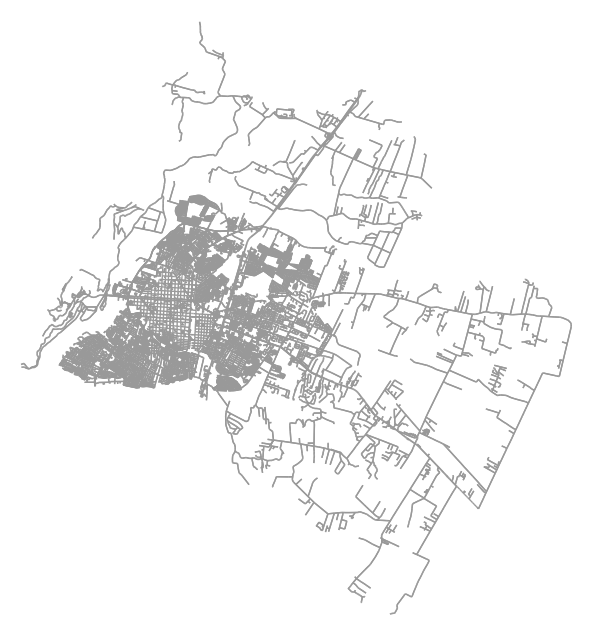

In [8]:
import osmnx as ox
import networkx as nx
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

G=ox.graph_from_place('Talca,Chile',network_type='all', simplify=False)
#ox.save_graphml(G, filename='talca_ciclovias.graphml')
plt.figure(figsize=(15,4))
ox.plot_graph(ox.project_graph(G),node_size=0, bgcolor='w')
plt.show()




In [9]:
for e in G.edges(data=True):
  print(e)
  break

(246009830, 9457990067, {'osmid': 702571679, 'highway': 'motorway', 'lanes': '2', 'maxspeed': '100', 'name': 'Ruta 5 Sur', 'oneway': True, 'ref': '5', 'reversed': False, 'length': np.float64(26.64990854595584)})


In [10]:
G.nodes[246009830],G.nodes[9457990067]

({'y': -35.355095, 'x': -71.57745, 'street_count': 2},
 {'y': -35.3548817, 'x': -71.577316, 'street_count': 2})

In [7]:
nx.is_weakly_connected(G)

True

In [1]:
stats=ox.basic_stats(G)
df=pd.DataFrame(pd.Series(stats)).T
display(df.T)

NameError: name 'ox' is not defined

In [15]:
G=G.to_undirected()

In [16]:
origin_point = (-35.434415,-71.620053)
destination_point = (-35.425901, -71.666645)
orig=ox.distance.nearest_nodes(G, origin_point[1],origin_point[0])
dest=ox.distance.nearest_nodes(G,destination_point[1],destination_point[0])

print('Inicio : ',G.nodes[orig])
print('Destino : ',G.nodes[dest])

Inicio :  {'y': -35.4343941, 'x': -71.6200764, 'street_count': 2}
Destino :  {'y': -35.425907, 'x': -71.666663, 'street_count': 3}


In [17]:
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

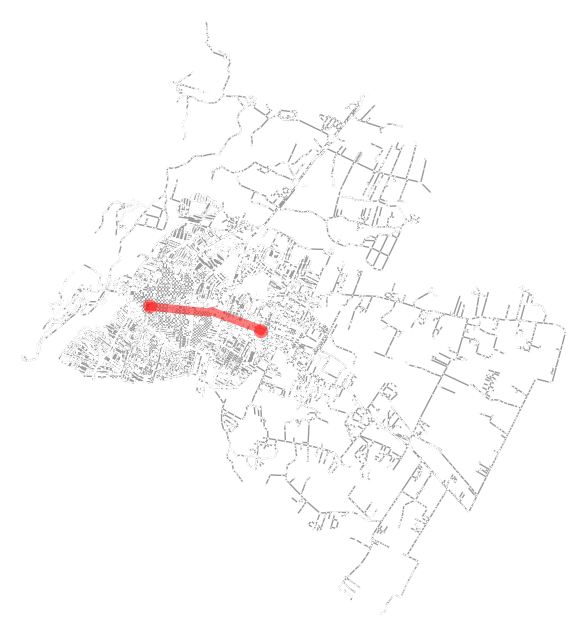

In [18]:
route = nx.shortest_path(G, orig, dest, weight='length')
fig, ax = ox.plot_graph_route(G, route, route_linewidth=6, node_size=1, bgcolor='w')

In [19]:
path_weight_km=nx.shortest_path_length(G,source=orig,target=dest,weight='length')/1000.
print('Largo del camino : {0:2.2f} [km] '.format(path_weight_km))

Largo del camino : 4.46 [km] 


# Algoritmo Dijkstra

El algoritmo de Dijkstra es un algoritmo utilizado para encontrar el camino más corto desde un nodo de origen a todos los demás nodos en un grafo con pesos no negativos en las aristas. En otras palabras, dado un grafo donde cada arista tiene un "costo" asociado, Dijkstra nos ayuda a encontrar la ruta más corta desde un punto de partida hasta cualquier otro punto del grafo.

**Conceptos clave:**

*   **Grafo:** Una colección de nodos (vértices) conectados por aristas (enlaces). En este caso, el grafo es ponderado, lo que significa que cada arista tiene un peso asociado (por ejemplo, la distancia entre dos ciudades).
*   **Peso de una arista:** Un valor numérico que representa el "costo" de atravesar esa arista.
*   **Camino:** Una secuencia de nodos conectados por aristas.
*   **Camino más corto:** El camino entre dos nodos con la suma de pesos de aristas más baja.
*   **Nodos visitados:** Un conjunto que lleva el registro de los nodos para los que ya hemos encontrado el camino más corto definitivo.
*   **Distancia:** En cada paso, mantenemos un registro de la distancia actual más corta conocida desde el nodo de origen a cada otro nodo. Inicialmente, la distancia al origen es 0, y la distancia a todos los demás nodos es infinito (o un valor muy grande que representa "desconocido").

**Funcionamiento del algoritmo:**

1.  **Inicialización:**
    *   Asignar una distancia de 0 al nodo de origen y una distancia de infinito a todos los demás nodos.
    *   Crear un conjunto de nodos no visitados, inicialmente conteniendo todos los nodos del grafo.

2.  **Iteración:** Mientras el conjunto de nodos no visitados no esté vacío:
    *   Seleccionar el nodo no visitado con la distancia más pequeña (esta es la parte "voraz" del algoritmo). Llamemos a este nodo el nodo actual.
    *   Mover el nodo actual del conjunto de nodos no visitados al conjunto de nodos visitados.
    *   Para cada vecino del nodo actual que aún no haya sido visitado:
        *   Calcular la distancia a través del nodo actual: `distancia(origen, vecino) = min(distancia(origen, vecino), distancia(origen, nodo_actual) + peso(nodo_actual, vecino))`
        *   Es decir, si la distancia desde el origen hasta el vecino a través del nodo actual es menor que la distancia actual conocida al vecino, actualizar la distancia del vecino.

3.  **Finalización:** Cuando el conjunto de nodos no visitados está vacío, hemos encontrado el camino más corto desde el nodo de origen a todos los demás nodos en el grafo. Las distancias calculadas representan las longitudes de los caminos más cortos.

**Pseudocódigo:**

```
funcion Dijkstra(grafo, nodo_origen):
  // Inicialización
  distancia = diccionario(nodo -> infinito) // Distancia desde el origen
  distancia[nodo_origen] = 0
  nodos_no_visitados = conjunto(todos los nodos en grafo)
  nodos_visitados = conjunto()

  mientras nodos_no_visitados no está vacío:
    // Seleccionar nodo no visitado con la distancia mínima
    nodo_actual = nodo con distancia mínima en nodos_no_visitados

    // Mover nodo al conjunto de visitados
    nodos_no_visitados.remover(nodo_actual)
    nodos_visitados.agregar(nodo_actual)

    // Actualizar distancias a los vecinos
    para cada vecino de nodo_actual que no esté en nodos_visitados:
      nueva_distancia = distancia[nodo_actual] + peso(nodo_actual, vecino)
      si nueva_distancia < distancia[vecino]:
        distancia[vecino] = nueva_distancia

  retornar distancia // Distancias más cortas desde el nodo_origen
```
**Consideraciones:**

*   El algoritmo de Dijkstra no funciona correctamente si hay aristas con pesos negativos. Para grafos con aristas negativas, se pueden usar otros algoritmos como el algoritmo de Bellman-Ford.
*   El algoritmo de Dijkstra es un algoritmo "voraz", ya que siempre selecciona el nodo no visitado más cercano en cada paso.
*   La eficiencia del algoritmo depende de cómo se implementen las estructuras de datos para el conjunto de nodos no visitados y la búsqueda del nodo con la distancia mínima. Usar una cola de prioridad (heap) es una forma común de optimizar el rendimiento.



In [20]:
import numpy as np
from heapq import heappush,heappop

class abstract_graph:

    def __init__(self,_edges):
        self.edges=_edges
        self.nodes={u for u,v in self.edges} | {v for u,v in self.edges}

    def adjacency_matrix(self):
        pass

    def adjacency_list(self):
        pass


class weighted_graph(abstract_graph):

    def __init__(self,_edges):
        tmp=dict()
        for (u,v),w in _edges.items():
            tmp.update({(u,v):w})
            if (v,u) not in tmp.keys() and v!=u:
                tmp.update({(v,u):w})
        self.edges=tmp
        self.nodes={u for u,v in _edges} | {v for u,v in _edges}

    def adjacency_matrix(self):
        n=len(self.nodes)
        mat=np.zeros((n,n))
        adjacent=lambda x : [1 if x==v else 0 for (u,v) in enumerate(sorted(list(G.nodes))) ]
        L=self.adjacency_list()
        i=0
        for v in sorted(list(G.nodes)):
            for l in L[v]:
                mat[i,]+=adjacent(l)
            i=i+1
        return mat

    def adjacency_list(self):
        adjacent=lambda n : {v for u,v in self.edges.keys() if u==n }
        return {v:adjacent(v) for v in self.nodes}

def dijkstra(G,start):
    if start not in G.nodes:
        return None
    neighbors=G.adjacency_list()
    path={}
    path.update({start:None})
    distance={}
    distance.update({start:0})
    frontier=[]
    heappush(frontier,(0,start))
    while frontier:
      dist_u,u=heappop(frontier)
      for v in neighbors[u]:
        dist_v=dist_u+G.edges[(u,v)]
        if v not in distance.keys() or dist_v<distance[v]:
          path.update({v:u})
          distance.update({v:dist_v})
          heappush(frontier,(dist_v,v))
    return path,distance

In [21]:
import haversine as hs
from haversine import Unit

data=G.nodes.data()
length = lambda u,v : hs.haversine((data[u]['y'],data[u]['x']),(data[v]['y'],data[v]['x']),
                                   unit=Unit.METERS)
E={(u,v):length(u,v) for u,v,w in G.edges}

In [22]:
G_2=weighted_graph(E)
parent,distance=dijkstra(G_2,orig)

In [23]:
path_weight_km=distance[dest]/1000.
print('Largo del camino : {0:2.2f} [km] '.format(path_weight_km))


Largo del camino : 4.46 [km] 


In [24]:
def tree_path(parent,end):
    path=[end]
    k=end
    while k is not None:
        path.append(parent[k])
        k=parent[k]
    return path[:-1][::-1]

In [25]:
route_2=tree_path(parent,dest)

In [26]:
for node in route_2:
  print(data[node])

{'y': -35.4343941, 'x': -71.6200764, 'street_count': 2}
{'y': -35.4344252, 'x': -71.6200944, 'street_count': 3}
{'y': -35.4344012, 'x': -71.6201719, 'street_count': 2}
{'y': -35.4342833, 'x': -71.620283, 'street_count': 2}
{'y': -35.4341946, 'x': -71.6203666, 'street_count': 3}
{'y': -35.4341289, 'x': -71.6204286, 'street_count': 2}
{'y': -35.4340802, 'x': -71.6204423, 'street_count': 2}
{'y': -35.4340338, 'x': -71.6204555, 'street_count': 2}
{'y': -35.4340166, 'x': -71.6204926, 'street_count': 3}
{'y': -35.4339111, 'x': -71.6204411, 'street_count': 3}
{'y': -35.4337787, 'x': -71.6207994, 'street_count': 2}
{'y': -35.4336108, 'x': -71.62139, 'street_count': 2}
{'y': -35.4335969, 'x': -71.6214395, 'street_count': 3}
{'y': -35.4335727, 'x': -71.621516, 'street_count': 2}
{'y': -35.4335697, 'x': -71.6215256, 'street_count': 2}
{'y': -35.4335512, 'x': -71.6215843, 'street_count': 3}
{'y': -35.4335077, 'x': -71.6215638, 'highway': 'crossing', 'street_count': 2}
{'y': -35.4334056, 'x': -71.6